In [1]:
from stable_baselines3 import PPO, TD3
from sb3_contrib import TQC, RecurrentPPO
from stable_baselines3.common.env_util import make_vec_env
from rl4greencrab import evaluate_agent, multiConstAction, simulator, plot_agent, CentroidAgent
import pandas as pd
import numpy as np
import ray
from skopt import gp_minimize, gbrt_minimize 
from skopt.plots import plot_convergence, plot_objective
from rl4greencrab import TwoActNormalized, twoActEnv

## Simulate agent actions in the environment

In [3]:
#obs = "count"
obs = "count-biomass-time"
config = {
    'random_start':True,
    'var_penalty_const': 0,
    'observation_type': obs,
    'control_randomness': True
}

In [3]:
dir_name = 'greencrab_two_act_env/count'

### Constant Action

In [3]:
# read in GP-optimized constant action
x = pd.read_csv("../data/constant_actions_result.csv").values[0].tolist()

In [ ]:
# create instance of env
evalEnv =  twoActEnv(config)

# read in GP-optimized constant action
x = pd.read_csv("../data/constant_actions_result.csv").values[0].tolist()

# turn action into agent
constant_agent = multiConstAction(env=evalEnv, action=np.array(x))
const_plot_agent = plot_agent(env_sim_df=None, 
                              agent_name='const_agent', 
                              env=evalEnv, 
                              agent=constant_agent, 
                              save_dir='.')

# run 500 simulations of environment and constant action "agent"                             
df = const_plot_agent.gen_env_sim_df(rep=500, obs_names=['crabs'])

# get just final timestep
df_subset = df[df['t'] == 99]

# save df
df_subset.to_csv('../data/const_agent_simulations.csv', index=False)

### RL Policy

In [ ]:
evalEnv =  TwoActNormalized(config)
ppoAgent = PPO.load(f"{agent_dir}/PPO-Var0-({obs})-1", device="cpu")
ppo_plot_agent = plot_agent(env_sim_df=None, 
                            agent_name=f'{dir_name}/ppo_agent_size', 
                            env=evalEnv, 
                            agent=ppoAgent, 
                            save_dir='.')
df = ppo_plot_agent.gen_env_sim_df(rep=500, obs_names=['crabs'])
ppo_plot_agent.save_df(ppo_plot_agent.env_simulation_df, 'ppo_size_sim_500')

### Clustered Policy

In [4]:
centroids = pd.read_csv("../clustering/centroids.csv")

evalEnv = TwoActNormalized(config)
centroid_agent = CentroidAgent(centroids=centroids, env=evalEnv)
centroid_plot_agent = plot_agent(env_sim_df=None,
                                 agent_name='centroid_agent',
                                 env=evalEnv,
                                 agent=centroid_agent,
                                 save_dir='.')
df = centroid_plot_agent.gen_env_sim_df(rep=500, obs_names=['crabs'])
#ppo_plot_agent.save_df(ppo_plot_agent.env_simulation_df, 'ppo_size_sim_500')

In [16]:
# get just final timestep
df_subset = df[df['t'] == 99]
df_subset.head()

,t,crabs,act0,act1,rew,rep,crab_pop,nonlocal_crab
99,99,"[-0.91897255, -0.80429494]",-0.964028,-0.631714,-7.667932,0,"[11179.273985279708, 5342.582057112939, 1.2304...","[84739.36435937966, 0.0, 82609.14807922786, 0...."
199,99,"[-0.9740107, -0.7531064]",-0.964028,0.227240,-5.982570,1,"[6461.446879197006, 3087.9295207579266, 0.7111...","[84739.36435937966, 0.0, 82609.14807922786, 0...."
299,99,"[-0.9711637, -0.7483277]",-0.964028,0.227240,-7.806545,2,"[7350.349811188674, 3512.7367901053863, 0.8090...","[84739.36435937966, 0.0, 82609.14807922786, 0...."
399,99,"[-0.9702689, -0.7575864]",-0.964028,0.227240,-4.456956,3,"[7387.2613829012325, 3530.3768534038636, 0.813...","[84739.36435937966, 0.0, 82609.14807922786, 0...."
499,99,"[-0.97018754, -0.73625493]",-0.964028,0.607146,-4.144993,4,"[7344.175170686521, 3509.7859255323056, 0.8083...","[84739.36435937966, 0.0, 82609.14807922786, 0...."


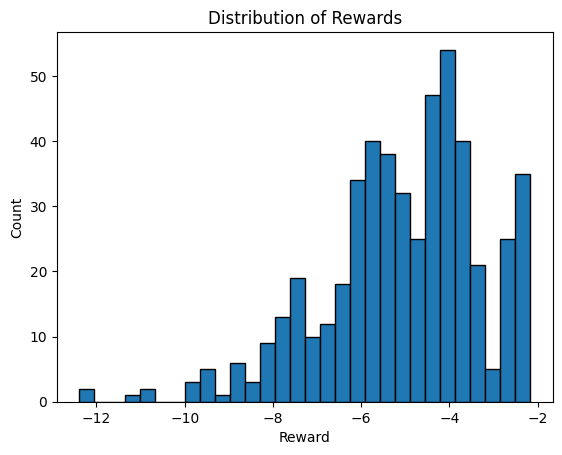

In [20]:
import matplotlib.pyplot as plt

plt.hist(df_subset['rew'], bins=30, edgecolor='black')
plt.xlabel('Reward')
plt.ylabel('Count')
plt.title('Distribution of Rewards')
plt.show()


In [22]:
df_subset['rew'].mean()


np.float64(-5.057694885022637)